# 01 — Data Understanding

## KKBOX Customer Churn Prediction Platform

### Objective

Notebook này thực hiện **QT2 — Thu thập, tìm hiểu và phân tích dữ liệu**.

Mục tiêu:

- Hiểu cấu trúc của 4 bảng dữ liệu KKBOX.
- Xác định grain của từng bảng.
- Kiểm tra số lượng record và user.
- Kiểm tra missing values.
- Kiểm tra duplicate records.
- Phát hiện giá trị bất thường và outlier.
- Phân tích phân bố target `is_churn`.
- Kiểm tra khoảng thời gian của dữ liệu.
- Kiểm tra coverage giữa các bảng theo `msno`.
- Thực hiện EDA cơ bản giữa dữ liệu và churn.
- Tổng hợp các vấn đề cần xử lý trong QT3.

> QT2 chỉ phát hiện và ghi nhận vấn đề. Không thực hiện Data Cleaning hoặc Feature Engineering chính thức.

## 1. Setup & Configuration

In [99]:
from pathlib import Path

import duckdb
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [100]:
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data" / "raw").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data" / "raw").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Không tìm thấy thư mục data/raw. "
        "Hãy chạy notebook từ root project hoặc thư mục notebooks."
    )

DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_PATH = DATA_DIR / "train_v2.csv"
MEMBERS_PATH = DATA_DIR / "members_v3.csv"
TRANSACTIONS_PATH = DATA_DIR / "transactions_v2.csv"
LOGS_PATH = DATA_DIR / "user_logs_v2.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: /home/namdp/Documents/AI_Projects/kkbox-churn-prediction
Data directory: /home/namdp/Documents/AI_Projects/kkbox-churn-prediction/data/raw


## 2. Data Inventory

Trước khi đọc dữ liệu, kiểm tra các file hiện có và dung lượng của từng file.

Điều này giúp lựa chọn công cụ xử lý phù hợp và tránh load các file rất lớn vào RAM một cách không cần thiết.

In [101]:
files = [
    TRAIN_PATH,
    MEMBERS_PATH,
    TRANSACTIONS_PATH,
    LOGS_PATH,
]

inventory = []

for path in files:
    inventory.append(
        {
            "file": path.name,
            "exists": path.exists(),
            "size_mb": path.stat().st_size / 1024**2 if path.exists() else None,
            "size_gb": path.stat().st_size / 1024**3 if path.exists() else None,
        }
    )

inventory_df = pd.DataFrame(inventory)

inventory_df

,file,exists,size_mb,size_gb
0,train_v2.csv,True,43.52,0.04
1,members_v3.csv,True,408.10,0.40
2,transactions_v2.csv,True,110.05,0.11
3,user_logs_v2.csv,True,"1,365.15",1.33


### Table Grain

| Dataset | Vai trò | Grain dự kiến |
|---|---|---|
| `train_v2.csv` | Target | 1 row / user |
| `members_v3.csv` | User profile | 0..1 row / user |
| `transactions_v2.csv` | Subscription/payment history | N rows / user |
| `user_logs_v2.csv` | Daily listening activity | N rows / user |

`transactions_v2.csv` và `user_logs_v2.csv` không thể được join trực tiếp vào training table trước khi aggregate về user-level.

Mục tiêu cuối của giai đoạn xử lý dữ liệu sau này là:

**1 `msno` = 1 row**

## 3. Train Dataset Analysis

`train_v2.csv` chứa danh sách user và target `is_churn`.

Các câu hỏi cần trả lời:

- Có bao nhiêu user?
- `msno` có unique không?
- Có missing values không?
- Target có đúng miền `{0, 1}` không?
- Tỷ lệ churn là bao nhiêu?
- Có class imbalance không?

In [102]:
train = pd.read_csv(
    TRAIN_PATH,
    dtype={
        "msno": "string",
        "is_churn": "int8",
    },
)

train.head()

,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1


In [103]:
print("Shape:", train.shape)
print()
train.info()

Shape: (970960, 2)

<class 'pandas.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   msno      970960 non-null  string
 1   is_churn  970960 non-null  int8  
dtypes: int8(1), string(1)
memory usage: 49.1 MB


In [104]:
train_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "unique_users",
            "duplicate_msno",
            "missing_msno",
            "missing_target",
        ],
        "value": [
            len(train),
            train["msno"].nunique(),
            train["msno"].duplicated().sum(),
            train["msno"].isna().sum(),
            train["is_churn"].isna().sum(),
        ],
    }
)

train_summary

,metric,value
0,rows,970960
1,unique_users,970960
2,duplicate_msno,0
3,missing_msno,0
4,missing_target,0


In [105]:
target_distribution = (
    train["is_churn"]
    .value_counts()
    .rename_axis("is_churn")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / len(train) * 100
)

target_distribution

,is_churn,count,percentage
0,0,883630,91.01
1,1,87330,8.99


In [106]:
print("Target values:", sorted(train["is_churn"].unique()))

Target values: [np.int8(0), np.int8(1)]


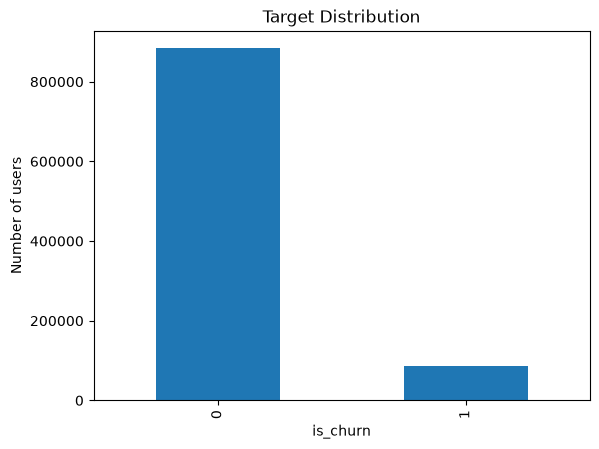

In [107]:
import matplotlib.pyplot as plt

train["is_churn"].value_counts().sort_index().plot(
    kind="bar",
    title="Target Distribution"
)

plt.xlabel("is_churn")
plt.ylabel("Number of users")
plt.show()

### Train Findings

- Dataset có **970,960 users**.
- `msno` không bị duplicate, do đó grain của bảng là **1 row = 1 user**.
- Không phát hiện missing value ở `msno` và `is_churn`.
- `is_churn` chỉ gồm hai giá trị hợp lệ `0` và `1`.
- Non-churn chiếm khoảng **91.01%**.
- Churn chiếm khoảng **8.99%**.
- Target có **class imbalance** khá rõ.

### Implication

Accuracy không nên được sử dụng làm metric chính ở giai đoạn đánh giá model.

Các metric cần quan tâm ở QT5 gồm Recall, Precision, F1-score, ROC-AUC và PR-AUC.

## 4. Members Dataset Analysis

`members_v3.csv` chứa thông tin hồ sơ người dùng.

Các vấn đề cần kiểm tra:

- Số record và user.
- Duplicate `msno`.
- Missing values.
- Tuổi `bd`.
- `gender`.
- `city`.
- `registered_via`.
- Khoảng thời gian đăng ký.

In [108]:
con = duckdb.connect()

con.execute(
    f"""
    CREATE OR REPLACE VIEW members_raw AS
    SELECT *
    FROM read_csv_auto('{MEMBERS_PATH.as_posix()}')
    """
)

con.execute(
    f"""
    CREATE OR REPLACE VIEW transactions_raw AS
    SELECT *
    FROM read_csv_auto('{TRANSACTIONS_PATH.as_posix()}')
    """
)

con.execute(
    f"""
    CREATE OR REPLACE VIEW logs_raw AS
    SELECT *
    FROM read_csv_auto('{LOGS_PATH.as_posix()}')
    """
)

con.execute(
    f"""
    CREATE OR REPLACE VIEW train_raw AS
    SELECT *
    FROM read_csv_auto('{TRAIN_PATH.as_posix()}')
    """
)

In [109]:
con.sql("""
    SELECT *
    FROM members_raw
    LIMIT 5
""").df()

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [110]:
members_summary = con.sql("""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT msno) AS unique_users,
        COUNT(*) - COUNT(DISTINCT msno) AS duplicate_user_rows
    FROM members_raw
""").df()

members_summary

,rows,unique_users,duplicate_user_rows
0,6769473,6769473,0


In [111]:
members_missing = con.sql("""
    SELECT
        SUM(CASE WHEN msno IS NULL THEN 1 ELSE 0 END) AS msno_missing,
        SUM(CASE WHEN city IS NULL THEN 1 ELSE 0 END) AS city_missing,
        SUM(CASE WHEN bd IS NULL THEN 1 ELSE 0 END) AS bd_missing,
        SUM(CASE WHEN gender IS NULL THEN 1 ELSE 0 END) AS gender_missing,
        SUM(CASE WHEN registered_via IS NULL THEN 1 ELSE 0 END) AS registered_via_missing,
        SUM(
            CASE WHEN registration_init_time IS NULL
            THEN 1 ELSE 0 END
        ) AS registration_time_missing
    FROM members_raw
""").df()

members_missing

,msno_missing,city_missing,bd_missing,gender_missing,registered_via_missing,registration_time_missing
0,0.00,0.00,0.00,"4,429,505.00",0.00,0.00


In [112]:
age_summary = con.sql("""
    SELECT
        MIN(bd) AS min_age,
        AVG(bd) AS mean_age,
        MEDIAN(bd) AS median_age,
        MAX(bd) AS max_age,

        SUM(
            CASE
                WHEN bd <= 0 OR bd > 100
                THEN 1
                ELSE 0
            END
        ) AS invalid_age_count,

        ROUND(
            100.0 *
            SUM(
                CASE
                    WHEN bd <= 0 OR bd > 100
                    THEN 1
                    ELSE 0
                END
            ) / COUNT(*),
            2
        ) AS invalid_age_pct

    FROM members_raw
""").df()

age_summary

,min_age,mean_age,median_age,max_age,invalid_age_count,invalid_age_pct
0,-7168,9.80,0.00,2016,"4,545,866.00",67.15


In [113]:
con.sql("""
    SELECT
        gender,
        COUNT(*) AS users,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
    FROM members_raw
    GROUP BY gender
    ORDER BY users DESC
""").df()

,gender,users,percentage
0,NaN,4429505,65.43
1,male,1195355,17.66
2,female,1144613,16.91


In [114]:
con.sql("""
    SELECT
        city,
        COUNT(*) AS users
    FROM members_raw
    GROUP BY city
    ORDER BY users DESC
    LIMIT 20
""").df()

,city,users
0,1,4804326
1,5,385069
2,13,320978
3,4,246848
4,22,210407
5,15,190213
6,6,135200
7,14,89940
8,12,66843
9,9,47639


In [115]:
con.sql("""
    SELECT
        registered_via,
        COUNT(*) AS users
    FROM members_raw
    GROUP BY registered_via
    ORDER BY users DESC
""").df()

,registered_via,users
0,4,2793213
1,3,1643208
2,9,1482863
3,7,805895
4,11,25047
5,13,5455
6,8,3982
7,5,3115
8,17,1494
9,2,1452


In [116]:
con.sql("""
    SELECT
        MIN(
            TRY_STRPTIME(
                CAST(registration_init_time AS VARCHAR),
                '%Y%m%d'
            )
        ) AS min_registration_date,

        MAX(
            TRY_STRPTIME(
                CAST(registration_init_time AS VARCHAR),
                '%Y%m%d'
            )
        ) AS max_registration_date,

        SUM(
            CASE
                WHEN TRY_STRPTIME(
                    CAST(registration_init_time AS VARCHAR),
                    '%Y%m%d'
                ) IS NULL
                THEN 1
                ELSE 0
            END
        ) AS invalid_registration_dates

    FROM members_raw
""").df()

,min_registration_date,max_registration_date,invalid_registration_dates
0,2004-03-26,2017-04-29,0.00


### Members Findings

- Dataset chứa khoảng **6.77 triệu user records**.
- `gender` thiếu khoảng **65.43%** dữ liệu.
- `bd` có vấn đề chất lượng dữ liệu nghiêm trọng.
- Khoảng **67%** giá trị `bd` nằm ngoài miền tuổi hợp lý `0 < age <= 100`.
- Có extreme values như tuổi âm và tuổi lên đến hàng nghìn.
- `registered_via` có một số category cần được kiểm tra, ví dụ `-1`.
- `registration_init_time` hiện được lưu dạng `YYYYMMDD` và cần được chuyển thành datetime ở QT3.

### Issues for QT3

- Xử lý invalid age.
- Xác định chiến lược xử lý missing gender.
- Kiểm tra category bất thường trong `registered_via`.
- Chuyển registration date thành datetime.

## 5. Transactions Dataset Analysis

`transactions_v2.csv` mô tả lịch sử thanh toán và subscription.

Các câu hỏi:

- Có bao nhiêu transaction?
- Có bao nhiêu user?
- Một user có bao nhiêu transaction?
- Có missing values không?
- Payment có giá trị bất thường không?
- Auto-renew và cancel phân bố như thế nào?
- Dữ liệu nằm trong khoảng thời gian nào?
- Có duplicate transaction không?

In [118]:
con.sql("""
    SELECT *
    FROM transactions_raw
    LIMIT 5
""").df()

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0
3,+/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=,36,30,180,180,1,20170329,20170331,1
4,+00PGzKTYqtnb65mPKPyeHXcZEwqiEzktpQksaaSC3c=,41,30,99,99,1,20170323,20170423,0


In [119]:
con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT msno) AS unique_users
    FROM transactions_raw
""").df()

,total_rows,unique_users
0,1431009,1197050


In [120]:
con.sql("""
    SELECT
        SUM(CASE WHEN msno IS NULL THEN 1 ELSE 0 END) AS msno_missing,
        SUM(CASE WHEN payment_method_id IS NULL THEN 1 ELSE 0 END) AS payment_method_missing,
        SUM(CASE WHEN payment_plan_days IS NULL THEN 1 ELSE 0 END) AS plan_days_missing,
        SUM(CASE WHEN plan_list_price IS NULL THEN 1 ELSE 0 END) AS plan_price_missing,
        SUM(CASE WHEN actual_amount_paid IS NULL THEN 1 ELSE 0 END) AS paid_missing,
        SUM(CASE WHEN is_auto_renew IS NULL THEN 1 ELSE 0 END) AS auto_renew_missing,
        SUM(CASE WHEN transaction_date IS NULL THEN 1 ELSE 0 END) AS transaction_date_missing,
        SUM(CASE WHEN membership_expire_date IS NULL THEN 1 ELSE 0 END) AS expire_date_missing,
        SUM(CASE WHEN is_cancel IS NULL THEN 1 ELSE 0 END) AS cancel_missing
    FROM transactions_raw
""").df()

,msno_missing,payment_method_missing,plan_days_missing,plan_price_missing,paid_missing,auto_renew_missing,transaction_date_missing,expire_date_missing,cancel_missing
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [121]:
con.sql("""
    WITH user_transactions AS (
        SELECT
            msno,
            COUNT(*) AS transaction_count
        FROM transactions_raw
        GROUP BY msno
    )

    SELECT
        MIN(transaction_count) AS min_transactions,
        AVG(transaction_count) AS avg_transactions,
        MEDIAN(transaction_count) AS median_transactions,
        MAX(transaction_count) AS max_transactions
    FROM user_transactions
""").df()

,min_transactions,avg_transactions,median_transactions,max_transactions
0,1,1.20,1.00,208


In [122]:
con.sql("""
    SELECT
        MIN(actual_amount_paid) AS min_paid,
        MEDIAN(actual_amount_paid) AS median_paid,
        AVG(actual_amount_paid) AS avg_paid,
        QUANTILE_CONT(actual_amount_paid, 0.95) AS p95_paid,
        QUANTILE_CONT(actual_amount_paid, 0.99) AS p99_paid,
        MAX(actual_amount_paid) AS max_paid,

        MIN(plan_list_price) AS min_plan_price,
        MAX(plan_list_price) AS max_plan_price
    FROM transactions_raw
""").df()

,min_paid,median_paid,avg_paid,p95_paid,p99_paid,max_paid,min_plan_price,max_plan_price
0,0,149.00,281.32,"1,788.00","1,788.00",2000,0,2000


In [123]:
con.sql("""
    SELECT
        SUM(
            CASE WHEN actual_amount_paid < 0
            THEN 1 ELSE 0 END
        ) AS negative_actual_amount,

        SUM(
            CASE WHEN plan_list_price < 0
            THEN 1 ELSE 0 END
        ) AS negative_plan_price,

        SUM(
            CASE WHEN payment_plan_days <= 0
            THEN 1 ELSE 0 END
        ) AS non_positive_plan_days

    FROM transactions_raw
""").df()

,negative_actual_amount,negative_plan_price,non_positive_plan_days
0,0.00,0.00,"2,218.00"


In [124]:
auto_renew_distribution = con.sql("""
    SELECT
        is_auto_renew,
        COUNT(*) AS rows,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
    FROM transactions_raw
    GROUP BY is_auto_renew
    ORDER BY is_auto_renew
""").df()

auto_renew_distribution

,is_auto_renew,rows,percentage
0,0,307234,21.47
1,1,1123775,78.53


In [125]:
cancel_distribution = con.sql("""
    SELECT
        is_cancel,
        COUNT(*) AS rows,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
    FROM transactions_raw
    GROUP BY is_cancel
    ORDER BY is_cancel
""").df()

cancel_distribution

,is_cancel,rows,percentage
0,0,1395876,97.54
1,1,35133,2.46


In [126]:
con.sql("""
    SELECT
        MIN(transaction_date) AS min_transaction_date,
        MAX(transaction_date) AS max_transaction_date,
        MIN(membership_expire_date) AS min_expire_date,
        MAX(membership_expire_date) AS max_expire_date
    FROM transactions_raw
""").df()

,min_transaction_date,max_transaction_date,min_expire_date,max_expire_date
0,20150101,20170331,20160419,20361015


In [127]:
con.sql("""
    SELECT COUNT(*) AS duplicate_groups

    FROM (
        SELECT
            *,
            COUNT(*) AS n
        FROM transactions_raw
        GROUP BY ALL
        HAVING COUNT(*) > 1
    )
""").df()

,duplicate_groups
0,0


### Transactions Findings

- Dataset chứa nhiều transaction records cho cùng một user.
- Grain của bảng là **N transactions / user**.
- Transactions phải được aggregate về `msno` trước khi tạo training table.
- Auto-renew và cancellation là những thuộc tính nghiệp vụ đáng chú ý.
- Payment có phân phối cần tiếp tục kiểm tra outlier ở QT3.
- `membership_expire_date` có một số giá trị rất xa trong tương lai và cần được xác minh.
- Không thực hiện xóa hoặc chỉnh sửa record ở QT2.

## 6. User Logs Dataset Analysis

`user_logs_v2.csv` chứa hành vi nghe nhạc theo ngày.

Các câu hỏi:

- Có bao nhiêu log records và users?
- Khoảng thời gian logs là gì?
- Có missing values không?
- Có duplicate `msno + date` không?
- `num_25` đến `num_100` phân bố thế nào?
- `num_unq` có đặc điểm gì?
- `total_secs` có giá trị bất thường không?
- Một user hoạt động bao nhiêu ngày?

In [128]:
con.sql("""
    SELECT *
    FROM logs_raw
    LIMIT 5
""").df()

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,"6,309.27"
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,"2,390.70"
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,"23,203.34"
3,ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=,20170331,176,4,2,2,19,191,"7,100.45"
4,EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=,20170331,2,1,0,1,112,93,"28,401.56"


In [129]:
con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT msno) AS unique_users
    FROM logs_raw
""").df()

,total_rows,unique_users
0,18396362,1103894


In [130]:
con.sql("""
    SELECT
        SUM(CASE WHEN msno IS NULL THEN 1 ELSE 0 END) AS msno_missing,
        SUM(CASE WHEN date IS NULL THEN 1 ELSE 0 END) AS date_missing,
        SUM(CASE WHEN num_25 IS NULL THEN 1 ELSE 0 END) AS num_25_missing,
        SUM(CASE WHEN num_50 IS NULL THEN 1 ELSE 0 END) AS num_50_missing,
        SUM(CASE WHEN num_75 IS NULL THEN 1 ELSE 0 END) AS num_75_missing,
        SUM(CASE WHEN num_985 IS NULL THEN 1 ELSE 0 END) AS num_985_missing,
        SUM(CASE WHEN num_100 IS NULL THEN 1 ELSE 0 END) AS num_100_missing,
        SUM(CASE WHEN num_unq IS NULL THEN 1 ELSE 0 END) AS num_unq_missing,
        SUM(CASE WHEN total_secs IS NULL THEN 1 ELSE 0 END) AS total_secs_missing
    FROM logs_raw
""").df()

,msno_missing,date_missing,num_25_missing,num_50_missing,num_75_missing,num_985_missing,num_100_missing,num_unq_missing,total_secs_missing
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [131]:
con.sql("""
    SELECT
        MIN(date) AS min_date,
        MAX(date) AS max_date
    FROM logs_raw
""").df()

,min_date,max_date
0,20170301,20170331


In [132]:
con.sql("""
    SELECT
        AVG(num_25) AS avg_num_25,
        AVG(num_50) AS avg_num_50,
        AVG(num_75) AS avg_num_75,
        AVG(num_985) AS avg_num_985,
        AVG(num_100) AS avg_num_100,
        AVG(num_unq) AS avg_num_unq,

        MAX(num_25) AS max_num_25,
        MAX(num_50) AS max_num_50,
        MAX(num_75) AS max_num_75,
        MAX(num_985) AS max_num_985,
        MAX(num_100) AS max_num_100,
        MAX(num_unq) AS max_num_unq

    FROM logs_raw
""").df()

,avg_num_25,avg_num_50,avg_num_75,avg_num_985,avg_num_100,avg_num_unq,max_num_25,max_num_50,max_num_75,max_num_985,max_num_100,max_num_unq
0,6.19,1.51,0.94,1.08,30.28,29.04,5639,912,508,1561,41107,4925


In [133]:
con.sql("""
    SELECT
        COUNT(*) AS invalid_rows
    FROM logs_raw
    WHERE total_secs < 0
       OR num_25 < 0
       OR num_50 < 0
       OR num_75 < 0
       OR num_985 < 0
       OR num_100 < 0
       OR num_unq < 0
""").df()

,invalid_rows
0,0


In [134]:
con.sql("""
    SELECT
        MIN(total_secs) AS min_secs,
        QUANTILE_CONT(total_secs, 0.50) AS p50_secs,
        QUANTILE_CONT(total_secs, 0.90) AS p90_secs,
        QUANTILE_CONT(total_secs, 0.95) AS p95_secs,
        QUANTILE_CONT(total_secs, 0.99) AS p99_secs,
        MAX(total_secs) AS max_secs
    FROM logs_raw
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_secs,p50_secs,p90_secs,p95_secs,p99_secs,max_secs
0,0.00,"4,582.99","19,476.59","28,188.53","43,805.52","9,194,058.52"


In [135]:
con.sql("""
    WITH user_activity AS (
        SELECT
            msno,
            COUNT(DISTINCT date) AS active_days
        FROM logs_raw
        GROUP BY msno
    )

    SELECT
        MIN(active_days) AS min_active_days,
        AVG(active_days) AS avg_active_days,
        MEDIAN(active_days) AS median_active_days,
        MAX(active_days) AS max_active_days
    FROM user_activity
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_active_days,avg_active_days,median_active_days,max_active_days
0,1,16.66,18.00,31


In [136]:
con.sql("""
    SELECT COUNT(*) AS duplicate_user_date_groups

    FROM (
        SELECT
            msno,
            date,
            COUNT(*) AS n
        FROM logs_raw
        GROUP BY msno, date
        HAVING COUNT(*) > 1
    )
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_user_date_groups
0,0


### User Logs Findings

- `user_logs_v2.csv` chứa khoảng **18.4 triệu records**.
- Có khoảng **1.10 triệu users**.
- Dữ liệu logs hiện tại nằm trong tháng **03/2017**.
- Một user có nhiều activity records.
- Grain của bảng là gần với **user-day level**.
- Trung bình user hoạt động khoảng **16.66 ngày** trong khoảng dữ liệu hiện có.
- `total_secs` có extreme values rất lớn cần được điều tra thêm.
- Các cột `num_25` đến `num_100` và `num_unq` có thể là nguồn feature hành vi quan trọng.
- Logs phải được aggregate về user-level trước khi modeling.

## 7. Cross-table Coverage

Không mặc định mọi user trong `train_v2` đều tồn tại trong `members`, `transactions` và `user_logs`.

Mục tiêu của phần này là đo tỷ lệ training users có dữ liệu ở từng source table.

In [137]:
coverage = con.sql("""
    WITH member_users AS (
        SELECT DISTINCT msno
        FROM members_raw
    ),

    transaction_users AS (
        SELECT DISTINCT msno
        FROM transactions_raw
    ),

    log_users AS (
        SELECT DISTINCT msno
        FROM logs_raw
    )

    SELECT
        COUNT(*) AS train_users,

        COUNT(m.msno) AS users_with_members,
        ROUND(
            COUNT(m.msno) * 100.0 / COUNT(*),
            2
        ) AS members_coverage_pct,

        COUNT(tx.msno) AS users_with_transactions,
        ROUND(
            COUNT(tx.msno) * 100.0 / COUNT(*),
            2
        ) AS transactions_coverage_pct,

        COUNT(l.msno) AS users_with_logs,
        ROUND(
            COUNT(l.msno) * 100.0 / COUNT(*),
            2
        ) AS logs_coverage_pct

    FROM train_raw t

    LEFT JOIN member_users m
        ON t.msno = m.msno

    LEFT JOIN transaction_users tx
        ON t.msno = tx.msno

    LEFT JOIN log_users l
        ON t.msno = l.msno
""").df()

coverage

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,train_users,users_with_members,members_coverage_pct,users_with_transactions,transactions_coverage_pct,users_with_logs,logs_coverage_pct
0,970960,860967,88.67,933578,96.15,754551,77.71


### Coverage Findings

- Khoảng **88.67%** training users có member profile.
- Khoảng **77.71%** training users có user logs.
- Transaction coverage được tính lại trong notebook mới.

Không phải mọi training user đều xuất hiện trong tất cả source tables.

### Implication for QT3

Không được tự động dùng INNER JOIN vì có thể làm mất một lượng lớn training users.

Feature tables nên được aggregate về `msno`, sau đó bắt đầu từ `train_v2` và cân nhắc `LEFT JOIN`.

Missing source data cần được xử lý có chủ đích thay vì tự động drop user.

## 8. Basic Churn EDA

Mục tiêu của phần này không phải tạo feature production.

Chỉ kiểm tra xem một số thuộc tính có khác biệt đáng chú ý giữa churn và non-churn users hay không.

Các quan sát ở đây chỉ dùng để hình thành giả thuyết Feature Engineering.

> Correlation hoặc khác biệt giữa các nhóm không chứng minh quan hệ nhân quả.

In [138]:
gender_churn = con.sql("""
    SELECT
        m.gender,
        COUNT(*) AS users,
        AVG(t.is_churn) AS churn_rate
    FROM train_raw t
    LEFT JOIN members_raw m
        ON t.msno = m.msno
    GROUP BY m.gender
    ORDER BY churn_rate DESC
""").df()

gender_churn

,gender,users,churn_rate
0,female,184344,0.13
1,male,204561,0.13
2,NaN,582055,0.06


In [139]:
registered_via_churn = con.sql("""
    SELECT
        m.registered_via,
        COUNT(*) AS users,
        AVG(t.is_churn) AS churn_rate
    FROM train_raw t
    LEFT JOIN members_raw m
        ON t.msno = m.msno
    GROUP BY m.registered_via
    ORDER BY churn_rate DESC
""").df()

registered_via_churn

,registered_via,users,churn_rate
0,4,52744,0.23
1,3,106459,0.17
2,9,235689,0.13
3,13,3391,0.10
4,<NA>,109993,0.05
5,7,462684,0.04


In [140]:
transaction_churn = con.sql("""
    WITH tx_features AS (
        SELECT
            msno,
            COUNT(*) AS tx_count,
            AVG(actual_amount_paid) AS avg_paid,
            AVG(is_auto_renew) AS auto_renew_rate,
            AVG(is_cancel) AS cancel_rate
        FROM transactions_raw
        GROUP BY msno
    )

    SELECT
        t.is_churn,

        COUNT(*) AS users,

        AVG(tx.tx_count) AS avg_tx_count,
        MEDIAN(tx.tx_count) AS median_tx_count,

        AVG(tx.avg_paid) AS avg_paid,

        AVG(tx.auto_renew_rate) AS avg_auto_renew_rate,
        AVG(tx.cancel_rate) AS avg_cancel_rate

    FROM train_raw t

    LEFT JOIN tx_features tx
        ON t.msno = tx.msno

    GROUP BY t.is_churn
    ORDER BY t.is_churn
""").df()

transaction_churn

,is_churn,users,avg_tx_count,median_tx_count,avg_paid,avg_auto_renew_rate,avg_cancel_rate
0,0,883630,1.16,1.00,129.00,0.93,0.01
1,1,87330,1.96,1.00,367.03,0.57,0.24


In [141]:
log_churn = con.sql("""
    WITH log_features AS (
        SELECT
            msno,
            COUNT(DISTINCT date) AS active_days,
            SUM(total_secs) AS total_secs,
            AVG(total_secs) AS avg_secs_per_day,
            AVG(num_unq) AS avg_unique_songs
        FROM logs_raw
        GROUP BY msno
    )

    SELECT
        t.is_churn,

        COUNT(*) AS users,

        AVG(l.active_days) AS mean_active_days,
        MEDIAN(l.active_days) AS median_active_days,

        AVG(l.total_secs) AS mean_total_secs,
        MEDIAN(l.total_secs) AS median_total_secs,

        AVG(l.avg_secs_per_day) AS mean_secs_per_day,
        MEDIAN(l.avg_secs_per_day) AS median_secs_per_day,

        AVG(l.avg_unique_songs) AS mean_unique_songs,
        MEDIAN(l.avg_unique_songs) AS median_unique_songs

    FROM train_raw t

    LEFT JOIN log_features l
        ON t.msno = l.msno

    GROUP BY t.is_churn
    ORDER BY t.is_churn
""").df()

log_churn

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,is_churn,users,mean_active_days,median_active_days,mean_total_secs,median_total_secs,mean_secs_per_day,median_secs_per_day,mean_unique_songs,median_unique_songs
0,0,883630,18.13,19.00,"141,113.08","83,814.77","6,473.17","4,708.15",24.29,19.20
1,1,87330,15.91,16.00,"126,291.23","70,180.34","6,456.91","4,717.18",24.71,19.50


### Basic Churn EDA Findings

#### Member profile

- Churn rate có sự khác biệt giữa một số nhóm `registered_via`.
- `gender` có missing rate cao, vì vậy mọi kết luận liên quan đến gender phải được diễn giải thận trọng.

#### Transactions

- Churn users có xu hướng có `cancel_rate` cao hơn.
- Churn users có xu hướng có `auto_renew_rate` thấp hơn.
- Payment behavior cho thấy sự khác biệt giữa hai nhóm.

#### Listening activity

- Median `active_days` của churn users: 16
- Median `active_days` của non-churn users: 19
- Median `total_secs` của churn users: 70,180.34
- Median `total_secs` của non-churn users: 83,814.77
- `avg_unique_songs` cho thấy ...

### Interpretation

Những khác biệt trên chỉ được xem là tín hiệu tiềm năng cho Feature Engineering ở QT3.

Không thể kết luận chúng là nguyên nhân trực tiếp gây churn.

# 9. Key Findings

## 9.1 Train

- `train_v2.csv` có 970,960 users.
- `msno` là unique.
- Không phát hiện missing target.
- Churn rate khoảng 8.99%.
- Target có class imbalance.

## 9.2 Members

- `members_v3.csv` chứa khoảng 6.77 triệu users.
- `gender` thiếu khoảng 65.43%.
- `bd` chứa một lượng rất lớn giá trị tuổi không hợp lệ.
- `registered_via` có một số category cần kiểm tra.
- `registration_init_time` cần chuyển thành datetime ở QT3.

## 9.3 Transactions

- Một user có thể có nhiều transaction records.
- Transactions cần được aggregate về user-level.
- Auto-renew và cancellation có dấu hiệu liên quan đến churn.
- Payment và membership expiration dates cần tiếp tục kiểm tra outlier/anomaly.

## 9.4 User Logs

- `user_logs_v2.csv` chứa khoảng 18.4 triệu records.
- Có khoảng 1.10 triệu users.
- Logs hiện có nằm trong tháng 03/2017.
- Một user có nhiều daily activity records.
- `total_secs` chứa extreme values cần điều tra.
- Listening logs cần được aggregate trước modeling.

## 9.5 Cross-table Relationship

Grain của dữ liệu:

- `train_v2`: 1 row / user.
- `members_v3`: 0..1 row / user.
- `transactions_v2`: N rows / user.
- `user_logs_v2`: N rows / user.

Không phải tất cả training users đều xuất hiện trong mọi source table.

## 9.6 Main Data Quality Risks

- Class imbalance.
- Invalid age values.
- Missing gender.
- Missing source data cho một số training users.
- Extreme listening duration.
- Potential anomalous dates.
- Duplicate event records nếu có.
- Data leakage nếu sử dụng dữ liệu sau prediction cutoff.

## 9.7 Important Constraint

QT3 phải đảm bảo:

**1 `msno` = 1 row**

và mọi feature theo thời gian phải chỉ sử dụng dữ liệu hợp lệ trước `cutoff_date`.